## _Building Graphs: Input Edges_

In [1]:
import glob, os, sys, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

In [5]:
# append parent dir
sys.path.append('..')

# local imports
from src import Compose_Event, Draw_Compose_Event

### _(+) - Input Data_

In [6]:
# input data
input_dir = '../train_all'

In [7]:
# Find All Input Data Files (hits.csv, cells.csv, particles.csv, truth.csv)
all_files = os.listdir(input_dir)

# Extract File Prefixes (use e.g. xxx-hits.csv)
suffix = '-hits.csv'
file_prefixes = sorted(os.path.join(input_dir, f.replace(suffix, ''))
                       for f in all_files if f.endswith(suffix))

In [8]:
# file_prefixes[:10]

In [9]:
event_id = 1
event_prefix = file_prefixes[event_id]

In [10]:
# load an event
hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

# memory usage
mem_bytes = (hits.memory_usage(index=True).sum() 
             + tubes.memory_usage(index=True).sum() 
             + particles.memory_usage(index=True).sum() 
             + truth.memory_usage(index=True).sum())

print('{} memory usage {:.2f} MB'.format(os.path.basename(event_prefix), mem_bytes / 2**20))

event0000000001 memory usage 0.03 MB


In [11]:
hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id
0,1,-1.745690,4.42021,0.881106,2,6,39
1,2,1.769520,-1.15347,2.420000,2,2,273
2,3,3.964660,-2.63097,5.443500,2,6,10
3,4,2.250330,4.17722,-7.071880,2,6,23
4,5,0.957682,1.98469,-3.248450,2,1,29


In [12]:
hits.layer_id.unique()

array([ 6,  2,  1,  7, 14, 17, 15, 23, 24, 25, 26, 27, 28,  0,  3,  4,  5,
       16, 18, 19, 20, 21, 22,  9, 11, 13], dtype=int32)

In [13]:
tubes.head()

,hit_id,depcharge,energyloss,volume_id,layer_id,module_id,sector_id,isochrone,skewed
0,1,14536.0,0.000052,2,6,39,NaN,NaN,NaN
1,2,19648.0,0.000071,2,2,273,NaN,NaN,NaN
2,3,19357.2,0.000070,2,6,10,NaN,NaN,NaN
3,4,43691.2,0.000158,2,6,23,NaN,NaN,NaN
4,5,34984.1,0.000126,2,1,29,NaN,NaN,NaN


In [14]:
particles.head()

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time,primary
0,1,0.0,0.0,0.0,0.737403,-0.161757,-0.468708,1,30,13,0,1
1,3,0.0,0.0,0.0,0.336343,0.236929,-0.099397,1,26,13,0,1
2,5,0.0,0.0,0.0,0.665995,0.641657,0.234167,1,27,13,0,1
3,6,0.0,0.0,0.0,0.357977,-0.229329,0.488361,-1,31,-13,0,1
4,7,0.0,0.0,0.0,0.387590,0.854636,-0.418559,-1,28,-13,0,1


In [15]:
truth.head()

,hit_id,tx,ty,tz,tpx,tpy,tpz,weight,particle_id
0,1,-1.744380,4.40974,0.878602,-0.244687,0.638028,0.126067,1.0,8
1,2,1.762170,-1.14845,2.410000,0.355199,-0.235100,0.486823,1.0,6
2,3,3.956490,-2.62517,5.432730,0.350848,-0.241165,0.486243,1.0,6
3,4,2.246700,4.16787,-7.056110,0.042684,0.060122,-0.116944,1.0,10
4,5,0.952562,1.97610,-3.232980,0.037278,0.070228,-0.119221,1.0,10


### _(+) - Build Event_

- functions from _event_utils.py_

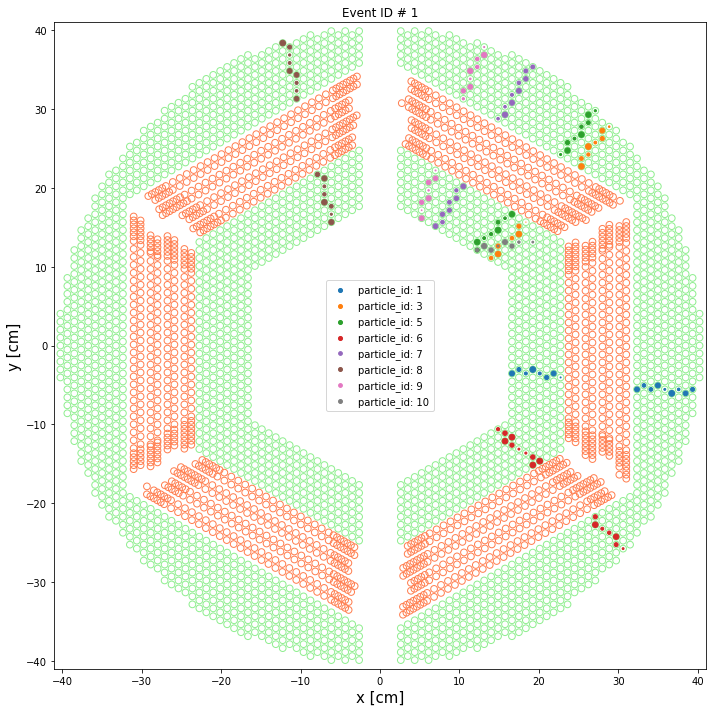

In [16]:
event = Compose_Event(event_prefix,skewed=False)
Draw_Compose_Event(event,figsize=(10,10));

In [17]:
event.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,isochrone,skewed,sector_id,...,px,py,pz,q,nhits,pdgcode,start_time,primary,pt,event_id
0,31,12.24560,12.120,35.0,9,0,93,0.185459,0.0,5.0,...,0.032401,0.074686,-0.118582,-1,12,-13,0,1,0.064776,1
1,39,5.24811,16.160,35.0,9,0,101,0.348950,0.0,5.0,...,0.225604,0.833752,0.053555,-1,25,-13,0,1,0.857121,1
2,64,-6.12280,15.655,35.0,9,0,5,0.414556,0.0,0.0,...,-0.258418,0.632729,0.127290,-1,27,-13,0,1,0.681559,1
3,89,6.99749,15.150,35.0,9,0,99,0.346619,0.0,5.0,...,0.387590,0.854636,-0.418559,-1,28,-13,0,1,0.936744,1
4,115,14.86970,-10.605,35.0,9,0,67,0.163050,0.0,3.0,...,0.357977,-0.229329,0.488361,-1,31,-13,0,1,0.424075,1


In [18]:
event.layer.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17])

## _Build Graphs_

### _(A) - True Edges (Layerwise)_

**True Graph** is the ground truth for GNN. It is built from creating edges from _`hits`_ from the same particle but in adjacent layers. 

For this purpose one has _`true_edges, hits = get_layerwise_edges(event)`_ function in the _`event_util.py`_.

In [19]:
from LightningModules.Processing.utils.event_utils import get_layerwise_edges

In [20]:
true_edges, hits = get_layerwise_edges(event)

In [21]:
hits.head()

,index,hit_id,x,y,z,volume_id,layer_id,module_id,isochrone,skewed,...,py,pz,q,nhits,pdgcode,start_time,primary,pt,event_id,R
0,0,228,10.748700,20.637300,0.048919,9,7,991,6.909880e-310,0.0,...,0.854636,-0.418559,-1,28,-13,0,1,0.936580,1,23.268759
1,1,215,7.249990,22.657301,0.154710,9,7,995,4.686430e-310,0.0,...,0.833752,0.053555,-1,25,-13,0,1,0.857038,1,23.789484
2,2,223,-8.124670,22.152300,-11.709400,9,7,861,6.909880e-310,0.0,...,0.632729,0.127290,-1,27,-13,0,1,0.681395,1,26.340933
3,3,246,16.871500,17.102301,19.162300,9,7,984,6.909880e-310,0.0,...,0.641657,0.234167,1,27,13,0,1,0.921240,1,30.729952
4,4,256,18.620899,16.092300,-18.985001,9,7,982,6.909880e-310,0.0,...,0.236929,-0.099397,1,26,13,0,1,0.405597,1,31.082636


In [22]:
# lets get unique pids with freq (~ hits).
sel_pids, sel_pids_fr = np.unique(hits.particle_id, return_counts=True)
print(sel_pids)

[ 1.  3.  5.  6.  7.  8.  9. 10.]


### _(B) - Input Edges (Layerwise)_

**Input Graph** is the training input to GNN. It is build from edges from hits from all particles but in adjacent layers.

- use same `hits` from `get_layerwise_edges()`
- make `get_input_graph()` function similar to `get_layerwise_edges()`
- add to Data variable.

In [23]:
# layer_groups.size()
# layer_groups.groups
# layer_groups.first()
# layer_groups.last()
# layer_groups.ngroups
# layer_groups.groups.keys()

In [24]:
def select_segments(hits1, hits2, filtering=True):
    
    # TODO: Impelement filtering flag
    # Start with all possible pairs of hits
    keys = ['event_id', 'r', 'phi', 'isochrone', 'sector_id']
    hit_pairs = hits1[keys].reset_index().merge(hits2[keys].reset_index(), on='event_id', suffixes=('_1', '_2'))
    
    if filtering:
        dSector = (hit_pairs['sector_id_1'] - hit_pairs['sector_id_2'])
        sector_mask = ((dSector.abs() < 2) | (dSector.abs() == 5))
        segments = hit_pairs[['index_1', 'index_2']][sector_mask]
    else:
        segments = hit_pairs[['index_1', 'index_2']]
        
    return segments

def construct_graph(hits, layer_pairs, filtering=True):
    """Construct one graph (e.g. from one event)"""

    # Loop over layer pairs and construct segments
    layer_groups = hits.groupby('layer')
    segments = []
    for (layer1, layer2) in layer_pairs:
        
        # Find and join all hit pairs
        try:
            hits1 = layer_groups.get_group(layer1)
            hits2 = layer_groups.get_group(layer2)
        # If an event has no hits on a layer, we get a KeyError.
        # In that case we just skip to the next layer pair
        except KeyError as e:
            logging.info('skipping empty layer: %s' % e)
            continue
        
        # Construct the segments
        segments.append(select_segments(hits1, hits2, filtering))
    
    # Combine segments from all layer pairs
    # segments = pd.concat(segments)
    return segments

In [25]:
# get number of layers, without skewed layers its just 18
n_layers = hits.layer.unique().shape[0]
print("total number of layers (w/o skewed): {}".format(n_layers))

total number of layers (w/o skewed): 18


In [26]:
# lets get pairs to adjacent layers
layers = np.arange(n_layers)
layer_pairs = np.stack([layers[:-1], layers[1:]], axis=1)
layer_pairs

array([[ 0,  1],
       [ 1,  2],
       [ 2,  3],
       [ 3,  4],
       [ 4,  5],
       [ 5,  6],
       [ 6,  7],
       [ 7,  8],
       [ 8,  9],
       [ 9, 10],
       [10, 11],
       [11, 12],
       [12, 13],
       [13, 14],
       [14, 15],
       [15, 16],
       [16, 17]])

In [27]:
# returns a list of indices from layer pairs.
segments = construct_graph(hits, layer_pairs, filtering=True)

In [28]:
# Combine segments from all layer pairs
# segments = pd.concat(segments)
# segments.describe()

In [29]:
# let's see the first layer pair (0th element)
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
#    print(segments[0][["index_1", "index_2"]])

In [30]:
# get the layer pari [0,1] from segments
edge_index = segments[0].to_numpy().T

In [31]:
edge_index.shape

(2, 57)

In [32]:
edge_index[0]

array([ 8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12,
       12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 17, 17, 17, 17,
       17, 17, 17, 17, 21, 21])

In [33]:
edge_index[1]

array([14, 15, 16, 18, 19, 20, 23, 26, 14, 16, 18, 19, 20, 23, 26, 14, 15,
       18, 19, 20, 23, 26, 29, 14, 15, 16, 18, 19, 20, 23, 26, 14, 15, 16,
       18, 19, 20, 23, 26, 14, 15, 16, 18, 19, 20, 23, 26, 14, 15, 16, 18,
       19, 20, 23, 26, 15, 29])

In [34]:
# hits.query("layer==0")

In [35]:
# hits.query("layer==1")

In [36]:
edge_index.shape[1] == len(segments[0])

True

### _(+) - Plotting Input Edges_

In [37]:
from src.drawing import detector_layout
from src.utils_math import polar_to_cartesian

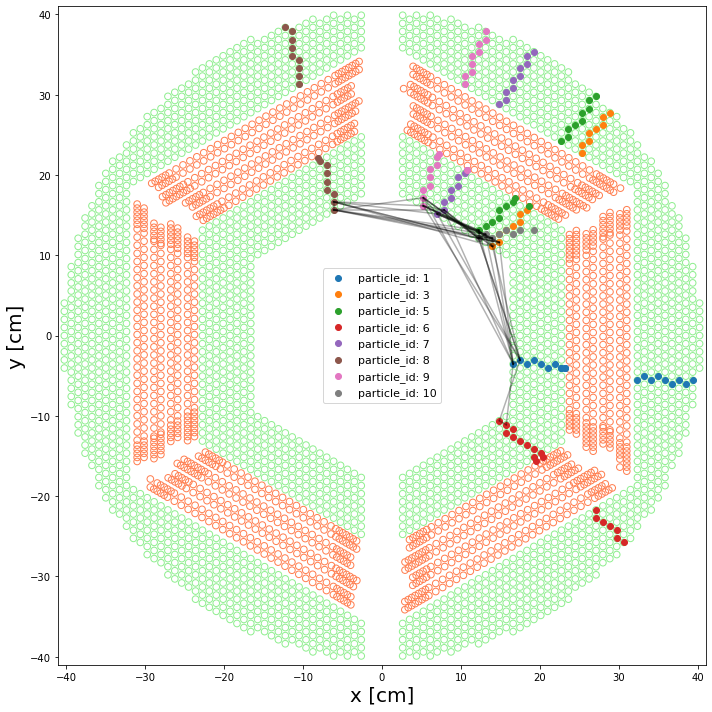

In [38]:
# plotting input_edges
plt.close('all')
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()

p_ids = np.unique(event.particle_id.values)
det = pd.read_csv("../src/stt.csv")
skw = det.query('skewed==0')
nkw = det.query('skewed==1') # one may look for +ve/-ve polarity
    
# detector layout
plt.scatter(skw.x.values, skw.y.values, s=44, facecolors='none', edgecolors='lightgreen')
plt.scatter(nkw.x.values, nkw.y.values, s=44, facecolors='none', edgecolors='coral')

# particle tracks
for pid in sel_pids:
    idx = hits.particle_id == pid
    ax.scatter(hits[idx].x.values, hits[idx].y.values, label='particle_id: %d' %pid)
    
# input edges
for iedge in range(edge_index.shape[1]):
    pt1 = hits.iloc[edge_index[0][iedge]]
    pt2 = hits.iloc[edge_index[1][iedge]]
    ax.plot([pt1.x, pt2.x], [pt1.y, pt2.y], color='k', alpha=0.3, lw=1.5)

# plotting params
ax.set_xlabel('x [cm]', fontsize=20)
ax.set_ylabel('y [cm]', fontsize=20)
# ax.set_title('Event ID # %d' % event_id)
ax.set_xlim(-41, 41)
ax.set_ylim(-41, 41)
ax.grid(False)
ax.legend(fontsize=11, loc='best')
fig.tight_layout()
fig.savefig("input_edges.pdf")

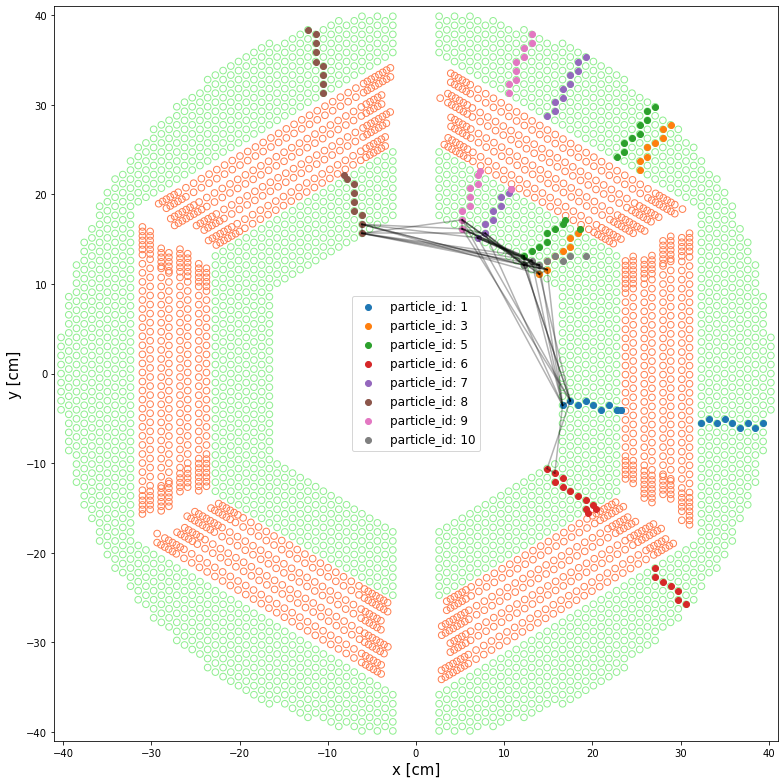

In [39]:
# New Plotting Scheme
fig, ax = detector_layout(figsize=(11,11))

# particle tracks
for pid in sel_pids:
    idx = hits.particle_id == pid
    ax.scatter(hits[idx].x.values, hits[idx].y.values, label='particle_id: %d' %pid)
    
# input edges
for iedge in range(edge_index.shape[1]):
    pt1 = hits.iloc[edge_index[0][iedge]]
    pt2 = hits.iloc[edge_index[1][iedge]]
    ax.plot([pt1.x, pt2.x], [pt1.y, pt2.y], color='k', alpha=0.3, lw=1.5)

# axis params
ax.legend(fontsize=12, loc='best')
fig.tight_layout()
# fig.savefig("input_edges.pdf")

### _(+) Sector-wise Filtering_

* build edges only in neighouring sectors _i.e._ `|sector_id_i - sector_id_j| < 2`

In [40]:
# lets take first layer_pair and corresponding hits
layer_pairs[0]

array([0, 1])

In [41]:
layer_groups = hits.groupby('layer')

In [42]:
hits1 = layer_groups.get_group(0)
hits2 = layer_groups.get_group(1)

In [43]:
keys = ['event_id', 'r', 'phi', 'isochrone', 'sector_id']
hit_pairs = hits1[keys].reset_index().merge(hits2[keys].reset_index(), on='event_id', suffixes=('_1', '_2'))
hit_pairs

,index_1,event_id,r_1,phi_1,isochrone_1,sector_id_1,index_2,r_2,phi_2,isochrone_2,sector_id_2
0,8,1,16.687941,1.138107,0.346619,5.0,14,17.522844,1.104869,0.198614,5.0
1,8,1,16.687941,1.138107,0.346619,5.0,15,17.754168,-0.171504,0.241745,4.0
2,8,1,16.687941,1.138107,0.346619,5.0,16,17.754181,1.922891,0.065543,0.0
3,8,1,16.687941,1.138107,0.346619,5.0,18,17.954153,0.820236,0.440331,5.0
4,8,1,16.687941,1.138107,0.346619,5.0,19,17.954151,1.274159,0.007010,5.0
...,...,...,...,...,...,...,...,...,...,...,...
67,21,1,18.264008,-0.619527,0.163050,3.0,19,17.954151,1.274159,0.007010,5.0
68,21,1,18.264008,-0.619527,0.163050,3.0,20,18.208044,0.766162,0.412063,5.0
69,21,1,18.264008,-0.619527,0.163050,3.0,23,18.513628,0.713723,0.298207,5.0
70,21,1,18.264008,-0.619527,0.163050,3.0,26,18.868391,0.663121,0.433445,5.0


In [44]:
sector_mask = ((hit_pairs['sector_id_1'] - hit_pairs['sector_id_2']).abs() < 2)

In [45]:
sector_mask

0      True
1      True
2     False
3      True
4      True
      ...  
67    False
68    False
69    False
70    False
71     True
Length: 72, dtype: bool

In [46]:
hit_pairs[['index_1', 'index_2']].head()

,index_1,index_2
0,8,14
1,8,15
2,8,16
3,8,18
4,8,19


In [47]:
hit_pairs[['index_1', 'index_2']][sector_mask].head()

,index_1,index_2
0,8,14
1,8,15
3,8,18
4,8,19
5,8,20
